# Testes de hipóteses paramétricos

Os métodos paramétricos são aplicados para dados quantitativos e exigem suposições fortes para sua validação, incluindo:

- as observações devem ser independentes;
- a amostra deve ser retirada de populações com determinada distribuição, geralmente a normal;
- as populações devem ter variâncias iguais para testes de comparação de duas médias populacionais emparelhadas ou $k$ médias populacionais ($k \ge 3$);
- as variáveis em estudo devem ser medidas em escala intervalar ou de razão, do modo que seja possível utilizar operações aritméticas sobre os respectivos valores.

## Teste t de Student para comparação de duas médias populacionais a partir de duas amostras aleatórias pareadas

Este teste é aplicado para verificar se as médias de duas amostras pareadas ou relacionadas, extraídas da mesma população (antes e depois) com distribuição normal, são ou não diferentes significativamente. Além da normalidade dos dados de cada amostra, o teste exige a homogeneidade das variâncias entre os grupos.

Para um teste bilateral, temos que:

$$
\begin{align}
H_0: & \mu_d = 0, \mu_d = \mu_{\text{antes}} - \mu_{\text{depois}} \\
H_1: & \mu_d \neq 0
\end{align}
$$

Exemplo: Um grupo de 10 operadores de máquinas, responsável por realizar determinada tarefa, é treinado para executar a mesma tarefa mais eficientemente. Para verificar se há alteração no tempo de execução da tarefa, mede-se o tempo gasto por cada operador, antes e depois do treinamento. Teste a hipótese de que as médias populacionais das duas amostras emparelhadas são semelhantes, isto é, de que não há diferença no tempo de execução da tarefa após o treinamento. Considere $\alpha = 5\%$.

In [1]:
import pandas as pd

BASE_TEMPO_OPERADORES = "./dados/operators.csv"

df_operadores = pd.read_csv(BASE_TEMPO_OPERADORES)

df_operadores

,operator_1,operator_2
0,3.2,3.0
1,3.6,3.3
2,3.4,3.5
3,3.8,3.6
4,3.4,3.4
5,3.5,3.3
6,3.7,3.4
7,3.2,3.0
8,3.5,3.2
9,3.9,3.6


In [2]:
df_operadores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   operator_1  10 non-null     float64
 1   operator_2  10 non-null     float64
dtypes: float64(2)
memory usage: 292.0 bytes


In [3]:
df_operadores.describe()

,operator_1,operator_2
count,10.000000,10.000000
mean,3.520000,3.330000
std,0.234758,0.216282
min,3.200000,3.000000
25%,3.400000,3.225000
50%,3.500000,3.350000
75%,3.675000,3.475000
max,3.900000,3.600000


<Axes: ylabel='Count'>

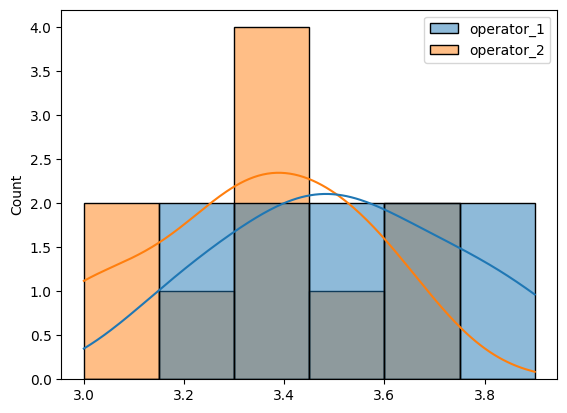

In [4]:
import seaborn as sns

sns.histplot(df_operadores, kde=True)

<Axes: >

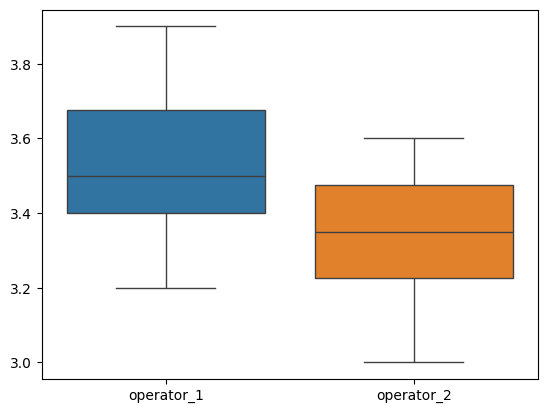

In [5]:
sns.boxplot(data=df_operadores)

In [6]:
from auxiliares import analises_shapiro_levene

analises_shapiro_levene(df_operadores)

teste de shapiro
 estatistica_sw =0.954
operator_1 segue uma distribuição normal (valor p: 0.715)
 estatistica_sw =0.920
operator_2 segue uma distribuição normal (valor p: 0.353)

teste de levene
estatistica_levene =0.061
Variancia Iguais (valor p: 0.808)


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html

In [7]:
from scipy.stats import ttest_rel

ttest_rel(df_operadores['operator_1'],df_operadores['operator_2'])

TtestResult(statistic=np.float64(4.384615384615384), pvalue=np.float64(0.0017592708301478821), df=np.int64(9))

Como $pvalue < 0.05$ a hipótese nula é rejeitada. Assim, conclui-se que existe diferença significativa entre o tempo dos operadores antes e depois do treinamento, ao nível de confiança de 95%.

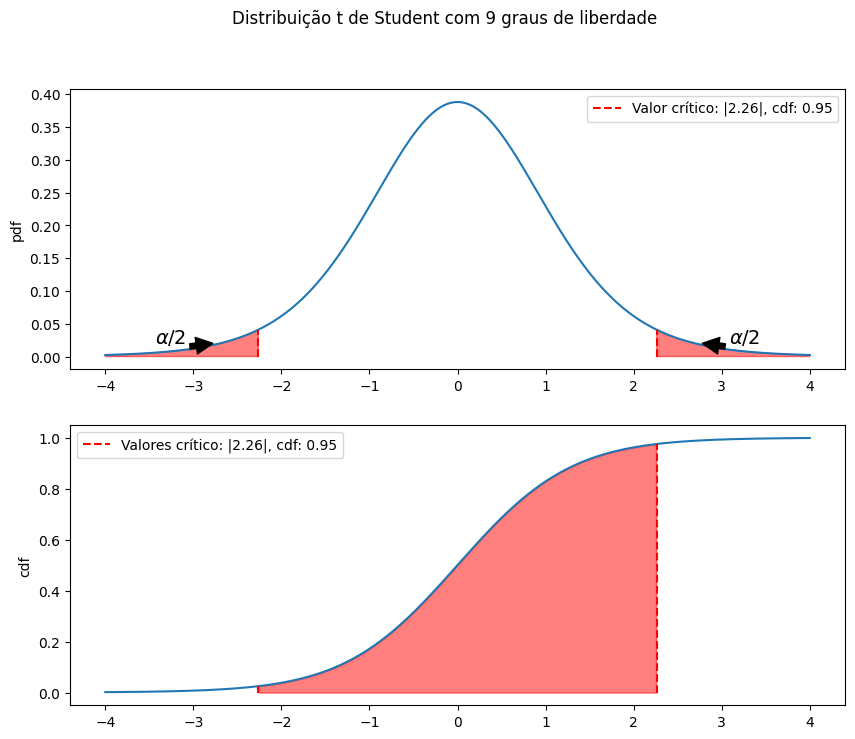

In [8]:
from graficos import plot_t_student

plot_t_student(9,0.05)

In [9]:
from scipy.stats import t

t.cdf(4.3846,9)

np.float64(0.9991203449053017)

In [10]:
(1-t.cdf(4.3846,9))*2

np.float64(0.001759310189396679)

In [11]:
from auxiliares import analise_ttest_rel

analise_ttest_rel(df_operadores)

teste de TT mais de uma variavel
estatistica_levene =4.385
Rejeita a hipótese nula (valor p: 0.002)
